# Testing against other software libraries

## Import dataset equal to part_b and project 1

In [1]:
# Import OLS dataset with code from proejct 1

from source.runge_preprocessing import x, y, X_train_scaled_ols, y_train_scaled_ols, X_test_scaled_ols, y_test_scaled_ols, y_train_std_ols, y_train_mean_ols, x_test, y_predicted_rescaled_ols, ETA_VALUES, NP_RANDOM_SEED

## PyTorch regression

Raschka page 435 - 436


In [2]:
import torch
import torch.nn as nn

from source.utils import pytorch_loop, rescale_predictions
from source.plotting import plot_runges_two_predictions, plot_heatmap
from source.utils import pytorch_model_fn


In [3]:
# Use design matrix made in part_b

X_train_scaled_tensor = torch.tensor(X_train_scaled_ols, dtype=torch.float32)
X_test_scaled_tensor = torch.tensor(X_test_scaled_ols, dtype=torch.float32)

y_train_scaled_tensor = torch.tensor(y_train_scaled_ols, dtype=torch.float32)
y_test_scaled_tensor = torch.tensor(y_test_scaled_ols, dtype=torch.float32)




In [4]:
# settings for this task

VERBOSE = True
SAVE_FIGURE = True

LAMBDA_VALUES = [0] #We use lambda = 0 in part_c only compareing to part_b

ffnn_iterations = 100

batch_size_val = 256

torch.manual_seed(NP_RANDOM_SEED)
act_func = nn.Sigmoid()

cost_f = 'MSE'


## 50 and 100 nodes in two hidden layers

In [5]:
# model generation - ensure new model each iteration


hidden_dim = [50, 100]
model_50_100_fn = lambda: pytorch_model_fn(hidden_dim, X_train_scaled_tensor, act_func, verbose=VERBOSE)


In [6]:
# loop through learning rates

# Plain SGD
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
pytorch_plain_SGD_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f, momentum=momentum_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# RMSprop 
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
rho1_val = 0.9
pytorch_RMSprop_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# ADAM
weight_decay_val = 0 # no lambda
rho1_val = 0.9
rho2_val = 0.999
pytorch_ADAM_results_50_100 = pytorch_loop(model_50_100_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor,
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f,momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, rho2=rho2_val, batch_size=batch_size_val, verbose=VERBOSE) 


MSELoss()

Training with optimizer=SGD, lr=0.1, lambda=0, iterations=100
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 0: Training Loss = 104.4460
Epoch 20: Training Loss = 0.9343
Epoch 40: Training Loss = 0.8329
Epoch 60: Training Loss = 0.7895
Epoch 80: Training Loss = 0.6714

Training with optimizer=SGD, lr=0.01, lambda=0, iterations=100
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=100, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=100, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.0546
Epoch 20: Training Loss = 1.0399
Epoch 40: Training Loss = 0.9330
Epoch 60: Training Loss = 0.9551
Epoch 80: Training Loss = 0.8536

Training with optimizer=SGD, lr=0.001, lambda=0, iterations=100
Sequential(
  (0): Lin

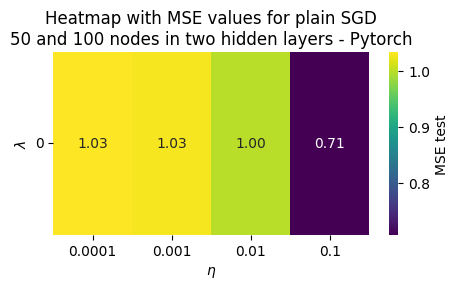

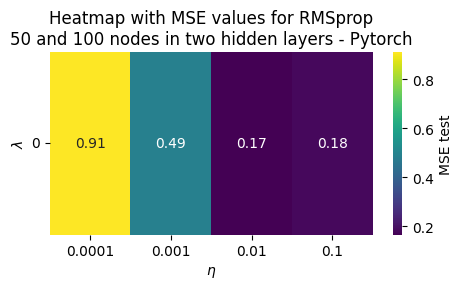

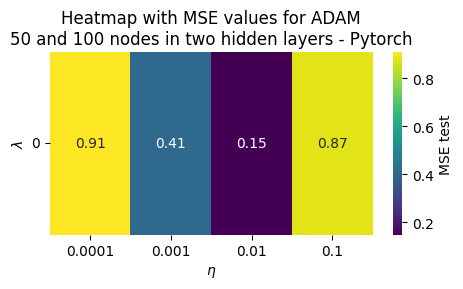

In [7]:
# Save heatmaps 

if SAVE_FIGURE:

    task = 'part_c'
    hidden_str = 'hidden50-100'
    algo = 'Pytorch'
    plot_type = 'heatmap'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_size_val}-{algo}'

    plot_heatmap(pytorch_plain_SGD_results_50_100, 'MSE test', y_axis_scientific=False, title='Heatmap with MSE values for plain SGD\n50 and 100 nodes in two hidden layers - Pytorch', filename = 'plain-sgd_' + filename_values)
    plot_heatmap(pytorch_RMSprop_results_50_100, 'MSE test', y_axis_scientific=False, title='Heatmap with MSE values for RMSprop\n50 and 100 nodes in two hidden layers - Pytorch', filename='rmsprop_' + filename_values)
    plot_heatmap(pytorch_ADAM_results_50_100, 'MSE test', y_axis_scientific=False, title='Heatmap with MSE values for ADAM\n50 and 100 nodes in two hidden layers - Pytorch', filename='adam_' + filename_values)

In [8]:
# Rescale predictions for best MSE

pytorch_best_predictions_plain_SGD_results_50_100_rescaled = rescale_predictions(pytorch_plain_SGD_results_50_100, y_train_std_ols, y_train_mean_ols)
pytorch_best_predictions_RMSprop_results_50_100_rescaled = rescale_predictions(pytorch_RMSprop_results_50_100, y_train_std_ols, y_train_mean_ols)
pytorch_best_predictions_ADAM_results_50_100_rescaled = rescale_predictions(pytorch_ADAM_results_50_100, y_train_std_ols, y_train_mean_ols)


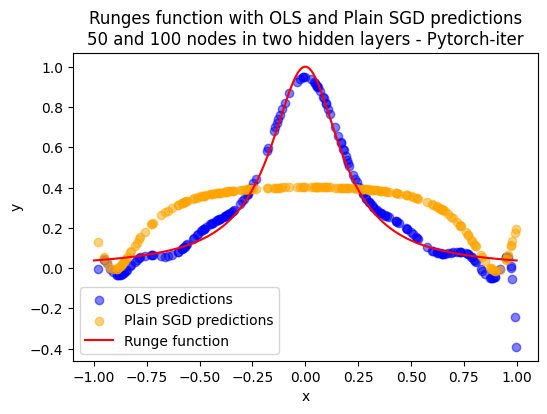

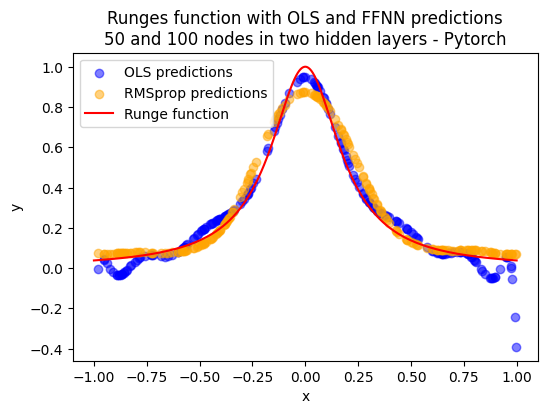

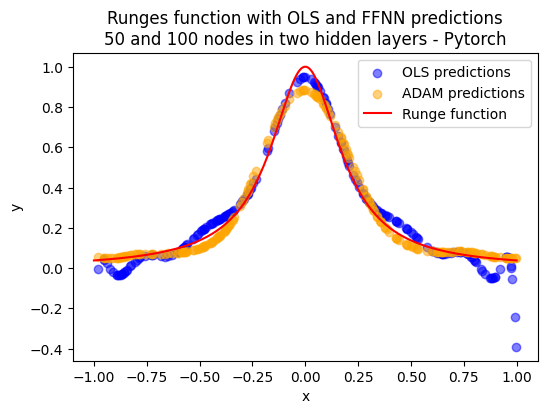

In [9]:
# Plot Runges Pytorch based on best MSE test value


if SAVE_FIGURE:

    task = 'part_c'
    hidden_str = 'hidden50-100'
    algo = 'Pytorch'
    plot_type = 'runges'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_size_val}-{algo}'

    # Plotting Runge function and predictions from OLS regression and FFNN
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_plain_SGD_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 and 100 nodes in two hidden layers - Pytorch-iter',
                                                            filename='plain-sgd_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_RMSprop_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers - Pytorch',
                                                            filename= 'rmsprop_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_ADAM_results_50_100_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 and 100 nodes in two hidden layers - Pytorch',
                                                            filename= 'adam_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

## 50 nodes in one hidden layers

In [10]:
# model generation - ensure new model each iteration


hidden_dim = [50]
model_50_fn = lambda: pytorch_model_fn(hidden_dim, X_train_scaled_tensor, nn.Sigmoid(), verbose=VERBOSE)




In [11]:
# loop through learning rates

# Plain SGD
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
pytorch_plain_SGD_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'SGD', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f, momentum=momentum_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# RMSprop 
momentum_val = 0 # Plain gradient descent
weight_decay_val = 0 # no lambda
rho1_val = 0.9
pytorch_RMSprop_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'RMSprop', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, batch_size=batch_size_val, verbose=VERBOSE) 

# ADAM
weight_decay_val = 0 # no lambda
rho1_val = 0.9
rho2_val = 0.999
pytorch_ADAM_results_50 = pytorch_loop(model_50_fn, ETA_VALUES, LAMBDA_VALUES, 'ADAM', ffnn_iterations, X_train_scaled_tensor, y_train_scaled_tensor, 
                                               X_test_scaled_tensor, y_test_scaled_tensor, cost_func=cost_f, momentum=momentum_val, rho=rho1_val, weight_decay=weight_decay_val, rho2=rho2_val, batch_size=batch_size_val, verbose=VERBOSE) 


MSELoss()

Training with optimizer=SGD, lr=0.1, lambda=0, iterations=100
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.1463
Epoch 20: Training Loss = 0.5740
Epoch 40: Training Loss = 0.4407
Epoch 60: Training Loss = 0.3560
Epoch 80: Training Loss = 0.3223

Training with optimizer=SGD, lr=0.01, lambda=0, iterations=100
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.1364
Epoch 20: Training Loss = 0.8094
Epoch 40: Training Loss = 0.7534
Epoch 60: Training Loss = 0.6773
Epoch 80: Training Loss = 0.5876

Training with optimizer=SGD, lr=0.001, lambda=0, iterations=100
Sequential(
  (0): Linear(in_features=16, out_features=50, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=50, out_features=1, bias=True)
)
Epoch 0: Training Loss = 1.1453


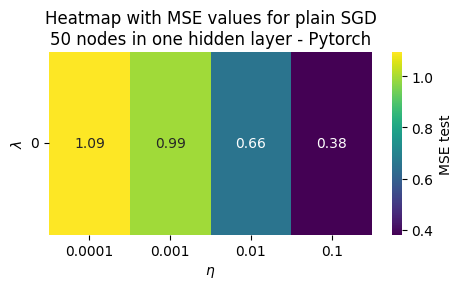

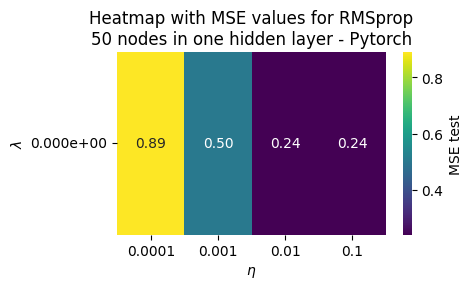

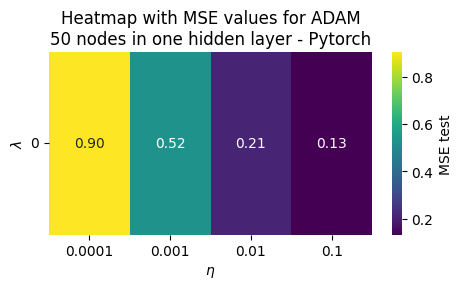

In [12]:

if SAVE_FIGURE:
    task = 'part_c'
    hidden_str = 'hidden50'
    algo = 'Pytorch'
    plot_type = 'heatmap'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_size_val}-{algo}'

    plot_heatmap(pytorch_plain_SGD_results_50, 'MSE test', y_axis_scientific=False, title='Heatmap with MSE values for plain SGD\n50 nodes in one hidden layer - Pytorch', filename='plain-sgd_' + filename_values)
    plot_heatmap(pytorch_RMSprop_results_50, 'MSE test', title='Heatmap with MSE values for RMSprop\n50 nodes in one hidden layer - Pytorch', filename='rmsprop_' + filename_values)
    plot_heatmap(pytorch_ADAM_results_50, 'MSE test', y_axis_scientific=False, title='Heatmap with MSE values for ADAM\n50 nodes in one hidden layer - Pytorch', filename='adam_' + filename_values)

In [13]:
# Rescale predictions for best MSE

pytorch_best_predictions_plain_SGD_results_50_rescaled = rescale_predictions(pytorch_plain_SGD_results_50, y_train_std_ols, y_train_mean_ols)
pytorch_best_predictions_RMSprop_results_50_rescaled = rescale_predictions(pytorch_RMSprop_results_50, y_train_std_ols, y_train_mean_ols)
pytorch_best_predictions_ADAM_results_50_rescaled = rescale_predictions(pytorch_ADAM_results_50, y_train_std_ols, y_train_mean_ols)


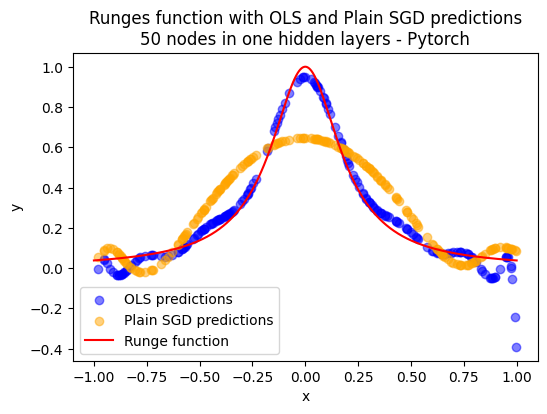

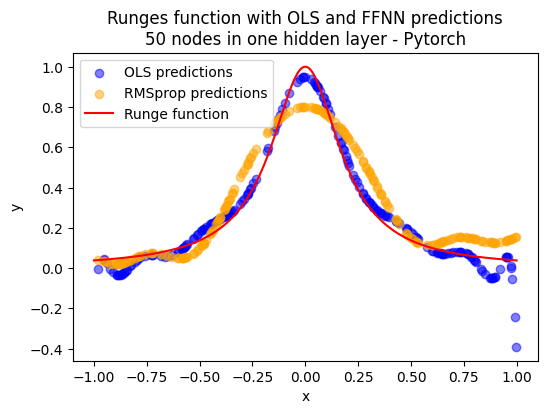

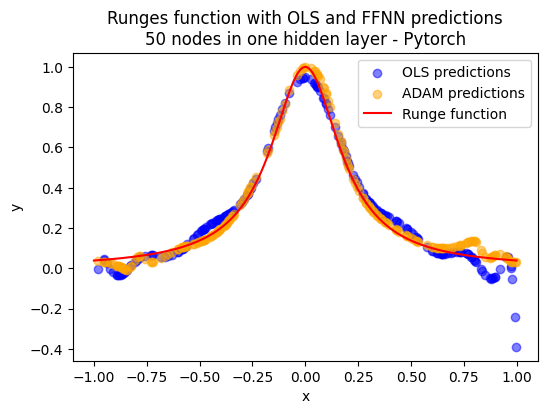

In [14]:
# Plot Runges Pytorch based on best MSE test value

if SAVE_FIGURE:
    # Plotting Runge function and predictions from OLS regression and FFNN

    task = 'part_c'
    hidden_str = 'hidden50'
    algo = 'Pytorch'
    plot_type = 'runge'

    filename_values = f'{task}-{plot_type}-{hidden_str}-iter{ffnn_iterations}-batch{batch_size_val}-{algo}'

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_plain_SGD_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='Plain SGD predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and Plain SGD predictions\n50 nodes in one hidden layers - Pytorch',
                                                            filename='plain-sgd_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)
                                                            
    
    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_RMSprop_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='RMSprop predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layer - Pytorch',
                                                            filename='rmsprop_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

    plot_runges_two_predictions(x, y, x_test, y_predicted_rescaled_ols, x_test, pytorch_best_predictions_ADAM_results_50_rescaled, 
                                                            label_scatter1='OLS predictions', label_scatter2='ADAM predictions', 
                                                            alpha_val=0.5, title='Runges function with OLS and FFNN predictions\n50 nodes in one hidden layer - Pytorch',
                                                            filename='adam_' + filename_values, save_image=SAVE_FIGURE, show_plot=SAVE_FIGURE)

# Comparing gradients from own implementation and autograd

In [15]:
from source.neural_network import NN

In [16]:
# Creating own implementaion of NN model

from source.utils import decide_activation_func, create_activations_layderdim
from source.cost_functions import class_mse_loss


## Hidden layers
hidden_50_100 = (50, 100)
act_func_task = 'sigmoid'     # Choose from 'RELU'  'LRELU' 'sigmoid'


## Set up input, hidden, and output layers and dimensions
activaton_func_50_100, activaton_func_derivative_50_100, output_func_50_100, output_func_derivative = decide_activation_func(act_func_task)
activations_50_100, activations_derivative_50_100, _dim_50_100 = create_activations_layderdim(activaton_func_50_100, activaton_func_derivative_50_100, 
                                                                         output_func_50_100, output_func_derivative, 
                                                                         hidden_50_100, y_train_scaled_ols, X_train_scaled_ols)

cost_fn = class_mse_loss(l1=0, l2=0) 
runge_NN = NN(_dim_50_100, activations_50_100, activations_derivative_50_100, cost_object=cost_fn)

In [17]:
# Functions for compareing autograd and own computation of gradients is a part of NN class

from source.runge_preprocessing import x_test, y_test
runge_NN.compare_gradients(X = X_train_scaled_ols, targets = y_train_scaled_ols)




Compare gradients between own and autograd calculations:
Layer 0: dW match: True, db match: True
Layer 1: dW match: True, db match: True
Layer 2: dW match: True, db match: True

Differences between own and autograd gradients
Layer 0 - dW diff:
[[ 5.20417043e-18  1.38777878e-17  0.00000000e+00  2.08166817e-17
   1.73472348e-18 -1.11022302e-16  0.00000000e+00  5.55111512e-17
   0.00000000e+00  0.00000000e+00  5.55111512e-17  4.98732999e-18
   2.77555756e-17  0.00000000e+00  6.93889390e-18  2.77555756e-17
   0.00000000e+00 -6.93889390e-18  0.00000000e+00  5.55111512e-17
   1.38777878e-17  0.00000000e+00  2.77555756e-17  0.00000000e+00
   2.77555756e-17 -6.93889390e-18  0.00000000e+00  1.11022302e-16
   5.55111512e-17  0.00000000e+00 -5.55111512e-17 -1.30104261e-18
   6.93889390e-18  0.00000000e+00 -6.93889390e-18 -4.16333634e-17
  -6.93889390e-18  0.00000000e+00 -6.93889390e-18 -2.77555756e-17
  -8.67361738e-19  1.38777878e-17  0.00000000e+00  0.00000000e+00
  -5.55111512e-17  0.00000000